In [1]:
import sys

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
from src.visualize import *

In [3]:
from src.data_pipeline import *

prices = download_data()
prices.head()

[data_pipeline] Loading cached prices from /Users/swastithakur/financial-regime-markov/data/spy_prices.csv


Date
2000-01-03    91.367531
2000-01-04    87.794510
2000-01-05    87.951561
2000-01-06    86.538048
2000-01-07    91.563866
Name: SPY, dtype: float64

In [4]:
type(prices)
type(prices.index)

pandas.DatetimeIndex

In [5]:
rolling_return = compute_rolling_return(prices)
print(rolling_return)

Date
2000-02-01   -0.030941
2000-02-02    0.009391
2000-02-03    0.022767
2000-02-04    0.035163
2000-02-07   -0.023157
                ...   
2024-12-23    0.001984
2024-12-24    0.009696
2024-12-26    0.004518
2024-12-27   -0.003035
2024-12-30   -0.020497
Name: rolling_return_20d, Length: 6268, dtype: float64


In [6]:
rolling_return10 = compute_rolling_return(prices, 10)
print(rolling_return10)

Date
2000-01-18    0.002578
2000-01-19    0.051878
2000-01-20    0.033928
2000-01-21    0.048548
2000-01-24   -0.037093
                ...   
2024-12-23   -0.013211
2024-12-24    0.000869
2024-12-26   -0.006743
2024-12-27   -0.012108
2024-12-30   -0.023188
Name: rolling_return_10d, Length: 6278, dtype: float64


In [7]:
regimes = classify_regimes(rolling_return)
regimes.head()

Date
2000-02-01       Bear
2000-02-02    Neutral
2000-02-03       Bull
2000-02-04       Bull
2000-02-07       Bear
Name: regime, dtype: category
Categories (3, str): ['Bull' < 'Neutral' < 'Bear']

Saved → ../visualizations/return_distribution.png


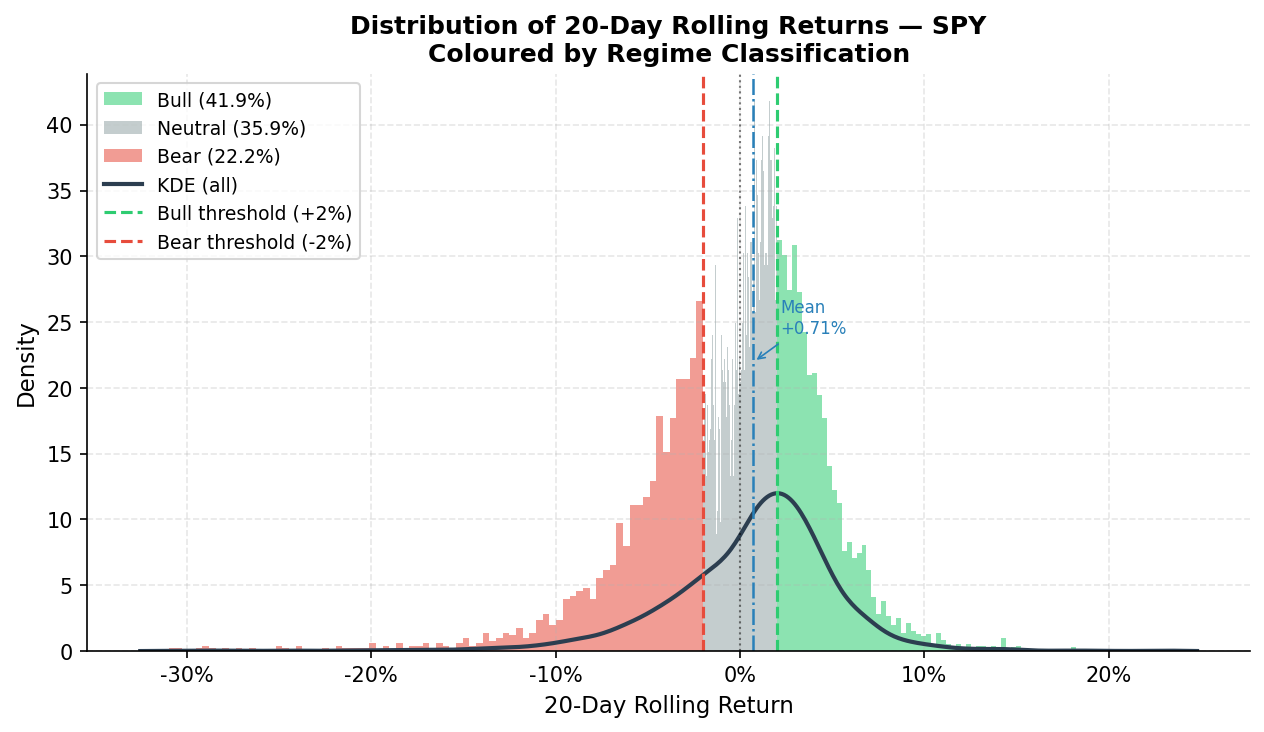

In [8]:
plot_return_distribution(rolling_return, regimes, save_path="../visualizations/return_distribution.png", show = False)

Saved → ../visualizations/regime_timeline.png


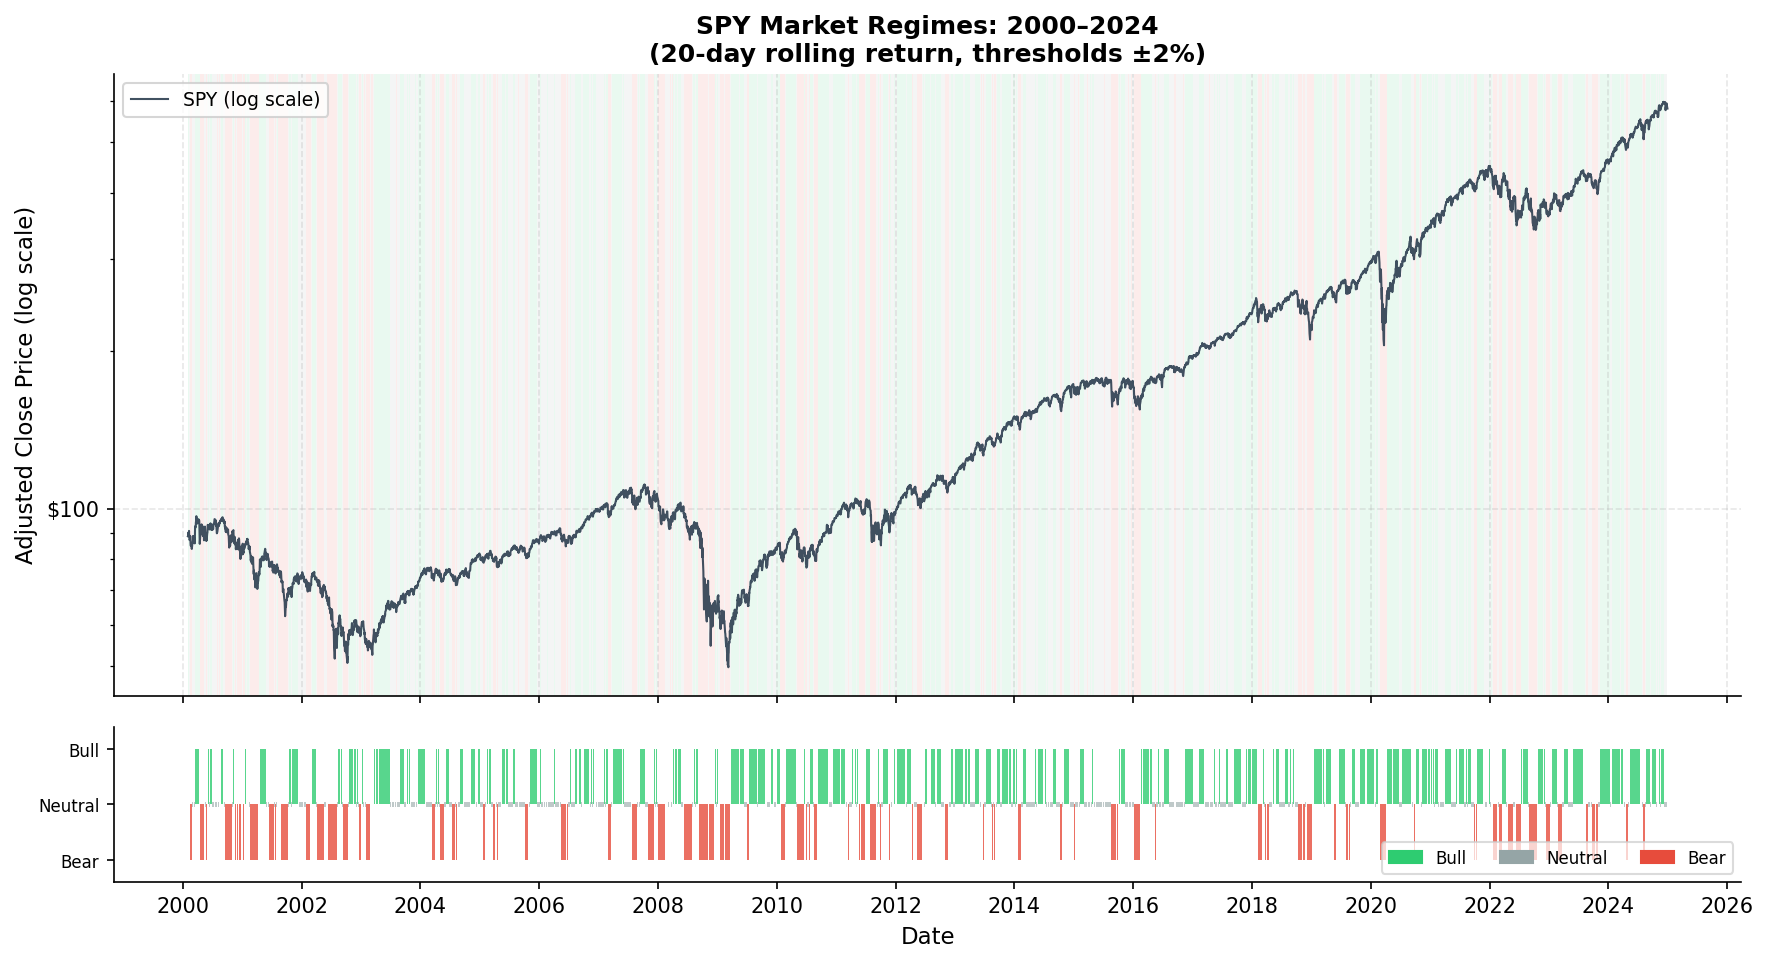

In [9]:
plot_regime_timeline(prices, regimes, save_path="../visualizations/regime_timeline.png", show = False)

In [10]:
records = run_lengths(regimes)
print(records)

       regime      start        end  length
0        Bear 2000-02-01 2000-02-01       1
1     Neutral 2000-02-02 2000-02-02       1
2        Bull 2000-02-03 2000-02-04       2
3        Bear 2000-02-07 2000-02-07       1
4     Neutral 2000-02-08 2000-02-08       1
...       ...        ...        ...     ...
1084     Bull 2024-11-20 2024-12-06      12
1085  Neutral 2024-12-09 2024-12-13       5
1086     Bull 2024-12-16 2024-12-17       2
1087  Neutral 2024-12-18 2024-12-27       7
1088     Bear 2024-12-30 2024-12-30       1

[1089 rows x 4 columns]


In [11]:
summary = regime_summary(regimes)
print(summary["counts"])
print(summary["frequencies"])
print(summary["mean_run"])
print(summary["median_run"])
print(summary["max_run"])
print(summary["n_transitions"])
#print(summary["nonoverlapping"])

regime
Bull       2628
Neutral    2251
Bear       1389
Name: count, dtype: int64
regime
Bull       0.419272
Neutral    0.359126
Bear       0.221602
Name: count, dtype: float64
regime
Bull       7.595376
Neutral    4.168519
Bear       6.842365
Name: length, dtype: float64
regime
Bull       3.0
Neutral    3.0
Bear       3.0
Name: length, dtype: float64
regime
Bull       46
Neutral    40
Bear       42
Name: length, dtype: int64
1088


Saved → ../visualizations/regime_frequencies.png


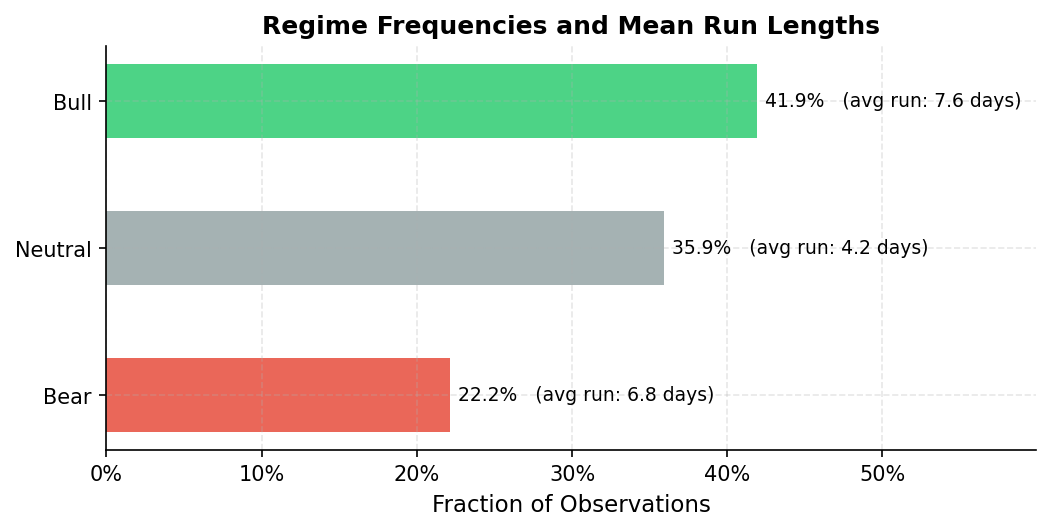

In [12]:
plot_regime_frequencies(summary, save_path="../visualizations/regime_frequencies.png", show = False)

In [13]:
print_summary(summary)

REGIME CLASSIFICATION SUMMARY
  Rolling window : 20 trading days
  Bull threshold : > +2%
  Bear threshold : < -2%
  Total obs.     : 6,268

  Regime        Count   Frequency    Mean run   Max run
  ----------  --------  ----------  ----------  --------
  Bull          2,628       41.9%         7.6        46
  Neutral       2,251       35.9%         4.2        40
  Bear          1,389       22.2%         6.8        42

  Total regime changes     : 1,088
  Non-overlapping obs.     : 314  (every 20th day)

  NOTE: Consecutive rolling-window observations overlap by
  19 days, biasing transition counts toward persistence.
  The non-overlapping subsample corrects for this.


In [14]:
from src.transition_matrix import *

In [15]:
counts = count_transitions(regimes)
print(counts)

[[2282  342    4]
 [ 342 1711  198]
 [   4  198 1186]]


In [16]:
P = mle_transition_matrix(counts)
print(P)

[[0.86834094 0.13013699 0.00152207]
 [0.15193247 0.76010662 0.08796091]
 [0.00288184 0.1426513  0.85446686]]


In [17]:
P_hat = laplace_smooth(counts)
print(P_hat)

[[0.8677309  0.13036868 0.00190042]
 [0.15217391 0.7595386  0.08828749]
 [0.00359454 0.14306254 0.85334292]]


Saved → ../visualizations/transition_heatmap.png


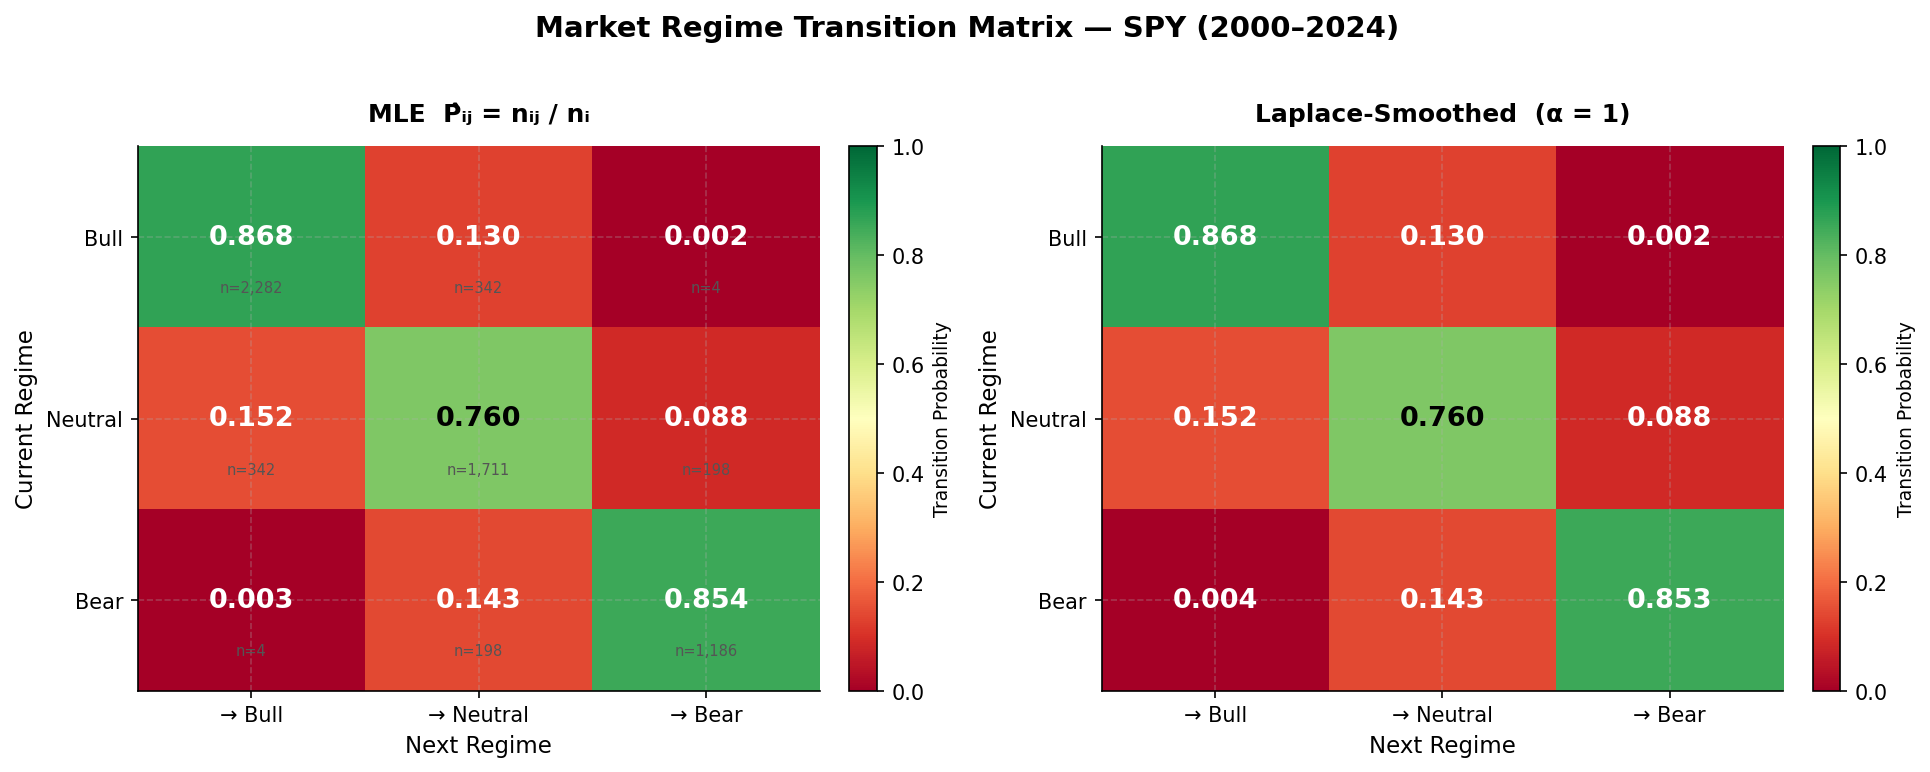

In [18]:
plot_transition_heatmap(P, P_hat, counts, save_path="../visualizations/transition_heatmap.png", show = False)

In [19]:
sim_labels = simulate_chain(P, 5, np.random.default_rng(0))
print(sim_labels)

0       Bear
1       Bear
2    Neutral
3       Bull
4       Bull
dtype: str


In [20]:
boot = bootstrap_ci(regimes)
print(boot)

{'point_estimate': array([[0.8677309 , 0.13036868, 0.00190042],
       [0.15217391, 0.7595386 , 0.08828749],
       [0.00359454, 0.14306254, 0.85334292]]), 'ci_lower': array([[8.54070469e-01, 1.18181401e-01, 7.72499034e-04],
       [1.38920613e-01, 7.41010219e-01, 7.72584311e-02],
       [1.48005906e-03, 1.25974768e-01, 8.32554051e-01]]), 'ci_upper': array([[0.87960445, 0.14354019, 0.00415095],
       [0.16770336, 0.77604657, 0.10041456],
       [0.00784664, 0.16300857, 0.87010664]]), 'ci_width': array([[0.02553398, 0.02535879, 0.00337845],
       [0.02878275, 0.03503635, 0.02315612],
       [0.00636658, 0.03703381, 0.03755258]]), 'ci_level': 0.95, 'n_bootstrap': 2000, 'bootstrap_samples': array([[[0.88017503, 0.11780545, 0.00201952],
        [0.16843629, 0.74324324, 0.08832046],
        [0.00567721, 0.14760746, 0.84671533]],

       [[0.86994329, 0.12741021, 0.0026465 ],
        [0.14814815, 0.76165577, 0.09019608],
        [0.00299401, 0.15643713, 0.84056886]],

       [[0.87175844, 

Saved → ../visualizations/bootstrap_ci.png


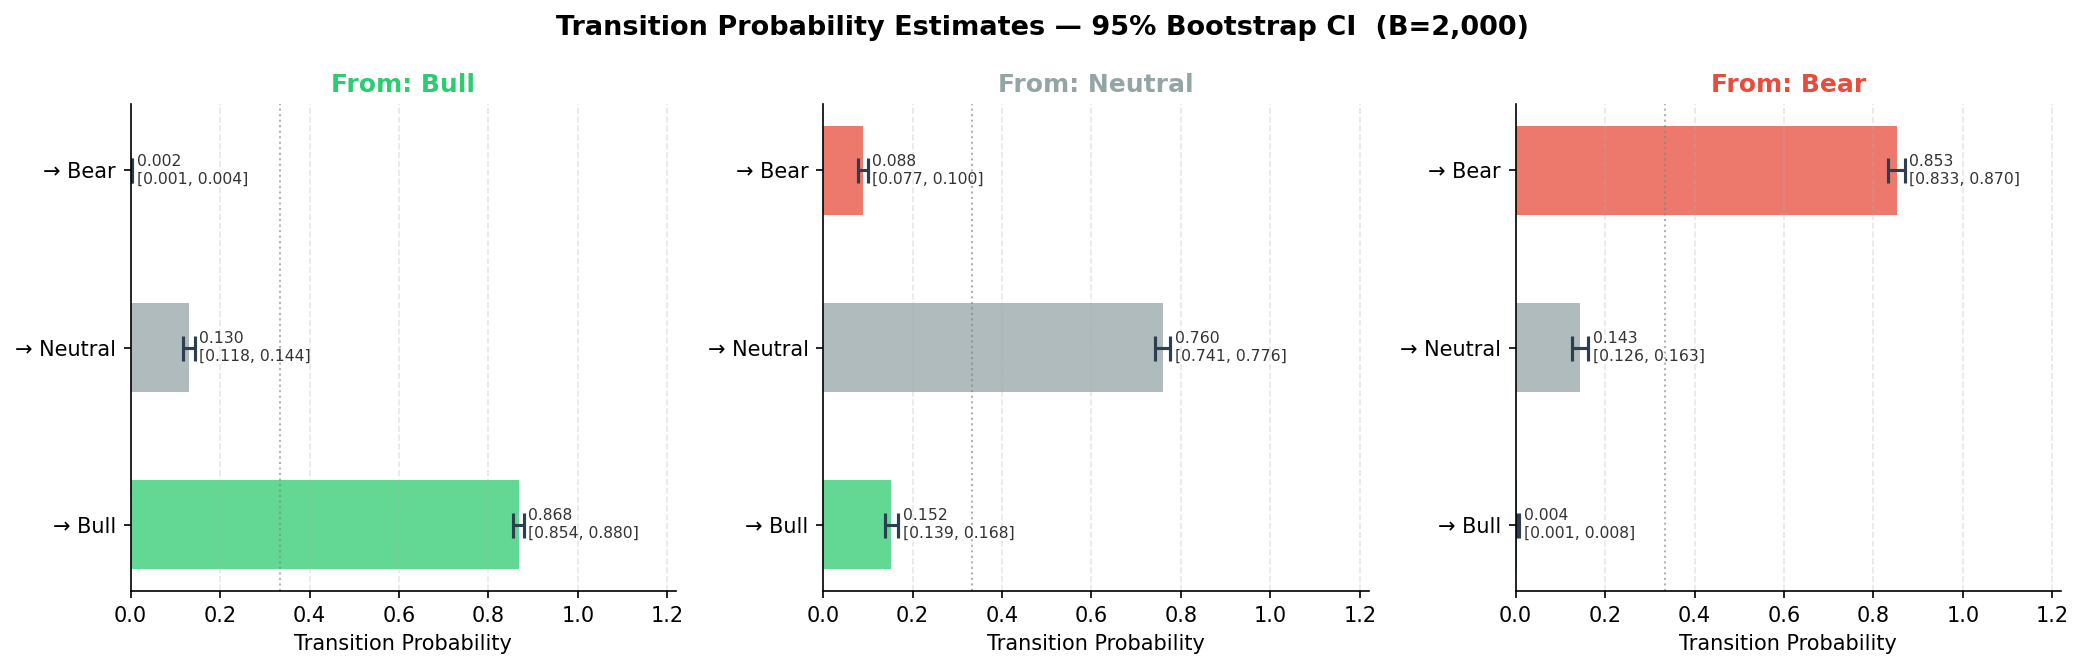

In [21]:
plot_bootstrap_ci(boot, save_path="../visualizations/bootstrap_ci.png", show = False)

In [22]:
print_matrix_summary(matrix_summary(regimes, verbose = False))

TRANSITION MATRIX ESTIMATION

RAW TRANSITION COUNTS  (rows = current state, cols = next state)
                    Bull     Neutral        Bear
  Bull           2,282       342         4
  Neutral          342     1,711       198
  Bear               4       198     1,186

MLE TRANSITION MATRIX  P̂ᵢⱼ = nᵢⱼ / nᵢ
                    Bull     Neutral        Bear
  Bull          0.8683    0.1301    0.0015
  Neutral       0.1519    0.7601    0.0880
  Bear          0.0029    0.1427    0.8545

LAPLACE-SMOOTHED MATRIX  (α=1 Dirichlet prior)
                    Bull     Neutral        Bear
  Bull          0.8677    0.1304    0.0019
  Neutral       0.1522    0.7595    0.0883
  Bear          0.0036    0.1431    0.8533

95% BOOTSTRAP CONFIDENCE INTERVALS  (B=2,000)
                        → Bull         → Neutral            → Bear
  Bull        0.868 [0.854,0.880]  0.130 [0.118,0.144]  0.002 [0.001,0.004]
  Neutral     0.152 [0.139,0.168]  0.760 [0.741,0.776]  0.088 [0.077,0.100]
  Bear        0.0

In [23]:
from src.markov_engine import *

In [24]:
power_iteration(P)

{'stationary': array([0.41933939, 0.35918302, 0.22147758]),
 'history': [0.037366776620847475,
  0.029976199336730902,
  0.024414294281069893,
  0.02012964434181208,
  0.016758433353853963,
  0.014056849178227582,
  0.01185843482072535,
  0.010047092476723973,
  0.008539921199912343,
  0.007325989745017247,
  0.006332929724852665,
  0.005462648453115948,
  0.004704621849889817,
  0.004047219505179223,
  0.0034788380287968934,
  0.0029885073654593586,
  0.0025661821520394368,
  0.0022028486404250813,
  0.0018905270153465326,
  0.001622217494386874,
  0.0013918191559824655,
  0.0011940384720341701,
  0.0010242971978860482,
  0.0008786448302131322,
  0.0007536781833398232,
  0.0006464690720465738,
  0.0005545001983696951,
  0.0004756088571308825,
  0.00040793783660553196,
  0.00034989279618913294,
  0.0003001053905235529,
  0.0002574014418549597,
  0.0002207735169631464,
  0.00018935732859134968,
  0.00016241144634179805,
  0.00013929986434577102,
  0.0001194770305943671,
  0.000102474994

Saved → ../visualizations/stationary_distribution.png


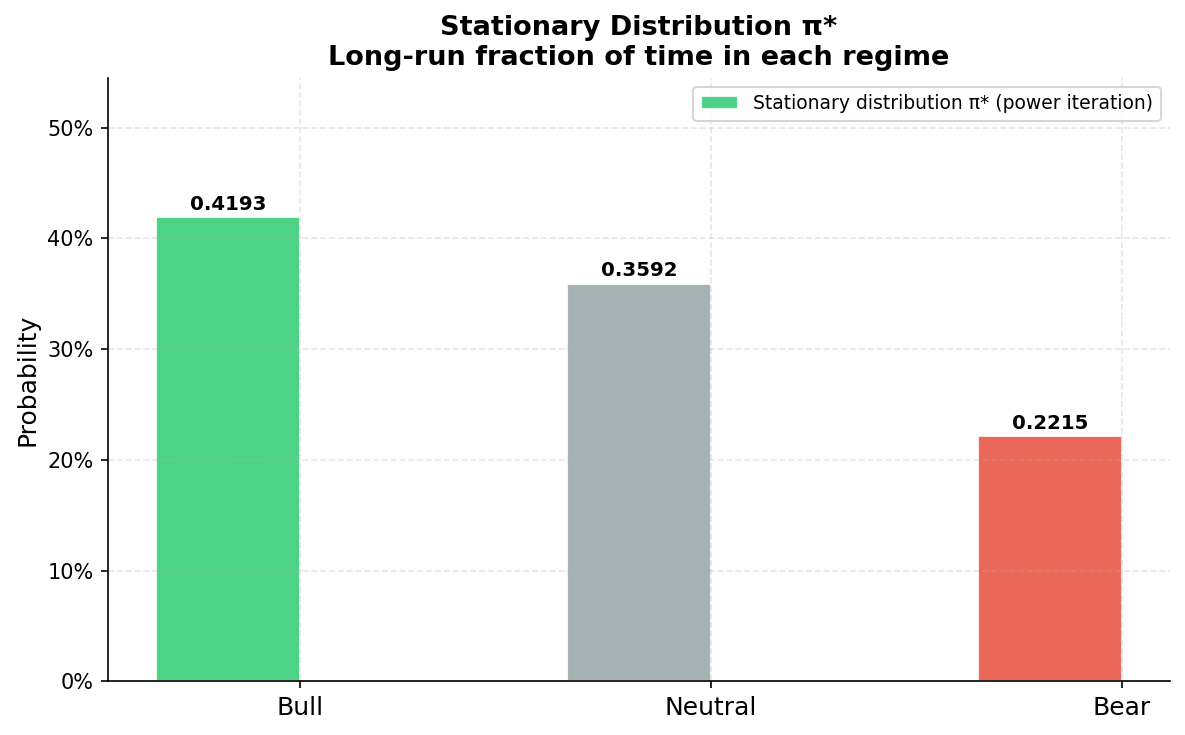

In [25]:
plot_stationary_distribution(power_iteration(P)["stationary"], save_path="../visualizations/stationary_distribution.png", show = False)

In [26]:
pi = eigenvector_stationary(P)
print(pi)

[0.4193394  0.35918302 0.22147758]


In [27]:
spectral = spectral_analysis(P)
print(spectral)

{'eigenvalues': array([0.62521951, 1.        , 0.85769491]), 'eigenvalues_abs': array([1.        , 0.85769491, 0.62521951]), 'lambda1': 1.0000000000000004, 'lambda2': 0.8576949089958699, 'spectral_gap': 0.14230509100413014, 'predicted_rate': 0.8576949089958699, 'mixing_time_est': 45, 'perron_frobenius_satisfied': True}


Saved → ../visualizations/eigenvalue_spectrum.png


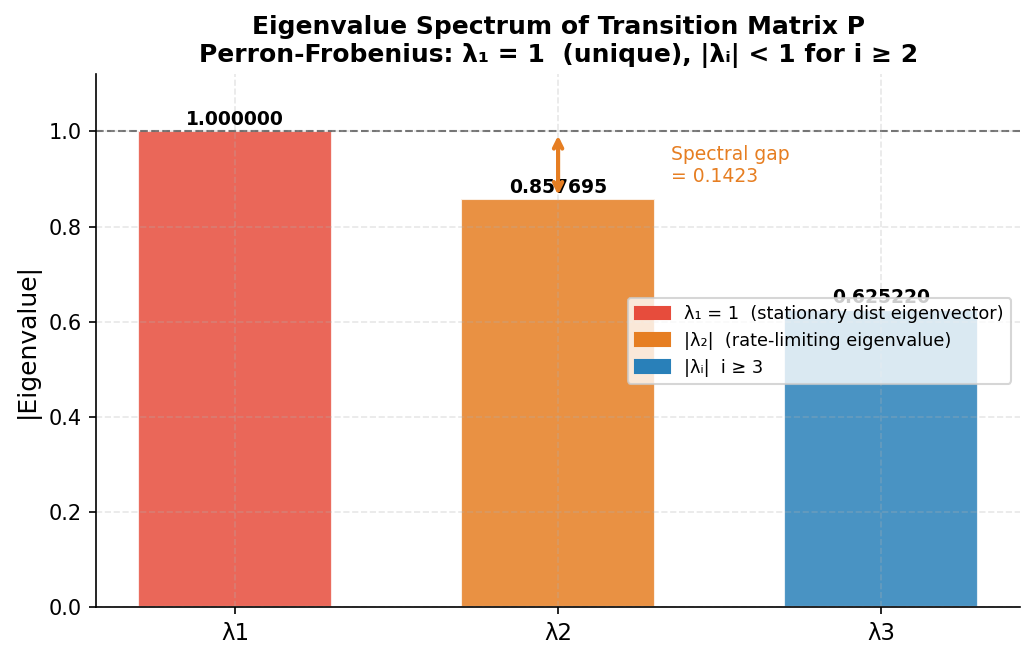

In [28]:
plot_eigenvalue_spectrum(spectral, save_path="../visualizations/eigenvalue_spectrum.png", show = False)

In [29]:
compare_methods(P)

{'pi_power': array([0.41933939, 0.35918302, 0.22147758]),
 'pi_eigen': array([0.4193394 , 0.35918302, 0.22147758]),
 'l1_diff': 5.2969672259539635e-09,
 'linf_diff': 2.6484844317664624e-09,
 'n_iter': 114,
 'converged': True,
 'history': [0.037366776620847475,
  0.029976199336730902,
  0.024414294281069893,
  0.02012964434181208,
  0.016758433353853963,
  0.014056849178227582,
  0.01185843482072535,
  0.010047092476723973,
  0.008539921199912343,
  0.007325989745017247,
  0.006332929724852665,
  0.005462648453115948,
  0.004704621849889817,
  0.004047219505179223,
  0.0034788380287968934,
  0.0029885073654593586,
  0.0025661821520394368,
  0.0022028486404250813,
  0.0018905270153465326,
  0.001622217494386874,
  0.0013918191559824655,
  0.0011940384720341701,
  0.0010242971978860482,
  0.0008786448302131322,
  0.0007536781833398232,
  0.0006464690720465738,
  0.0005545001983696951,
  0.0004756088571308825,
  0.00040793783660553196,
  0.00034989279618913294,
  0.0003001053905235529,
  0

In [30]:
multi_init = multi_init_convergence(P)
print(multi_init)

{'results': {'Uniform [1/3,1/3,1/3]': {'stationary': array([0.41933939, 0.35918302, 0.22147758]), 'history': [0.037366776620847475, 0.029976199336730902, 0.024414294281069893, 0.02012964434181208, 0.016758433353853963, 0.014056849178227582, 0.01185843482072535, 0.010047092476723973, 0.008539921199912343, 0.007325989745017247, 0.006332929724852665, 0.005462648453115948, 0.004704621849889817, 0.004047219505179223, 0.0034788380287968934, 0.0029885073654593586, 0.0025661821520394368, 0.0022028486404250813, 0.0018905270153465326, 0.001622217494386874, 0.0013918191559824655, 0.0011940384720341701, 0.0010242971978860482, 0.0008786448302131322, 0.0007536781833398232, 0.0006464690720465738, 0.0005545001983696951, 0.0004756088571308825, 0.00040793783660553196, 0.00034989279618913294, 0.0003001053905235529, 0.0002574014418549597, 0.0002207735169631464, 0.00018935732859134968, 0.00016241144634179805, 0.00013929986434577102, 0.0001194770305943671, 0.0001024749947625414, 8.789237751583023e-05, 7.538

Saved → ../visualizations/state_trajectories.png


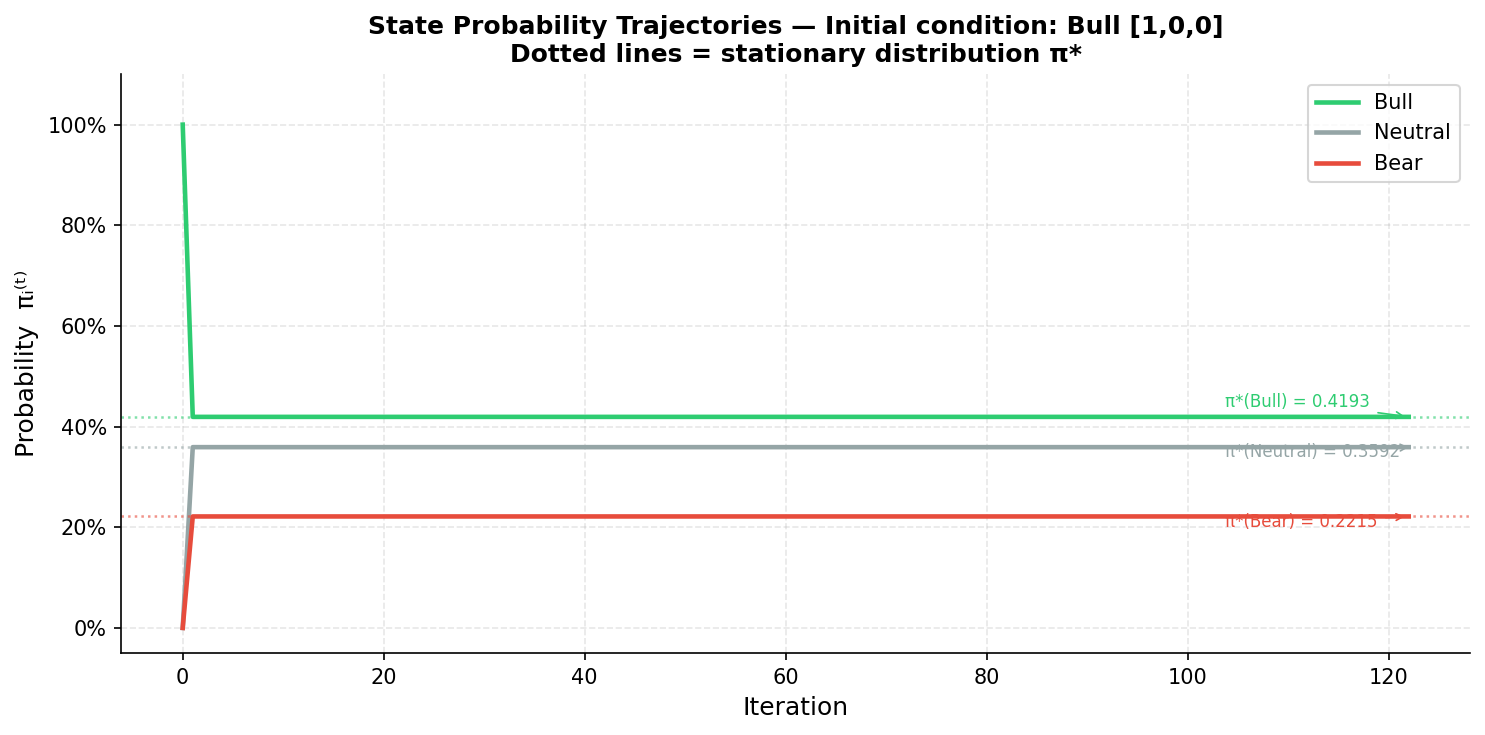

In [31]:
plot_state_trajectories(multi_init, save_path="../visualizations/state_trajectories.png", show = False)

In [32]:
convergence_rate = fit_convergence_rate(power_iteration(P)["history"])
print(convergence_rate)

{'empirical_rate': 0.8576949090402721, 'log_rate': -0.15350682659825615, 'fit_r2': 1.0, 'fit_start': 57}


Saved → ../visualizations/convergence.png


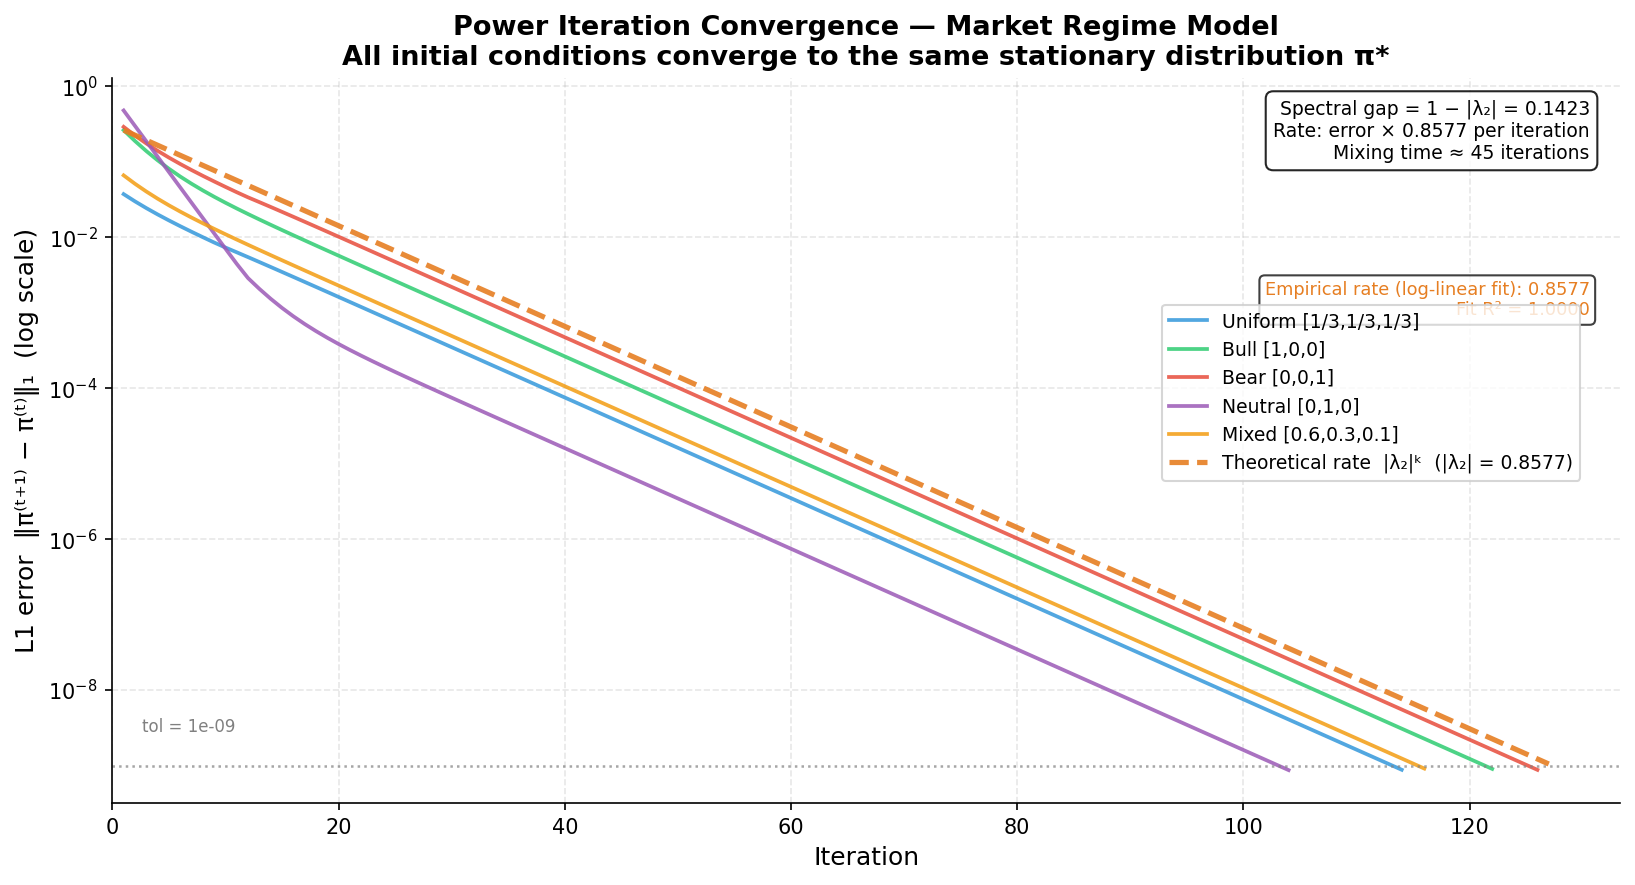

In [33]:
plot_convergence(multi_init, spectral, convergence_rate, save_path="../visualizations/convergence.png", show = False)

In [34]:
pagerank_cmp = pagerank_comparison(P)

Saved → ../visualizations/pagerank_comparison.png


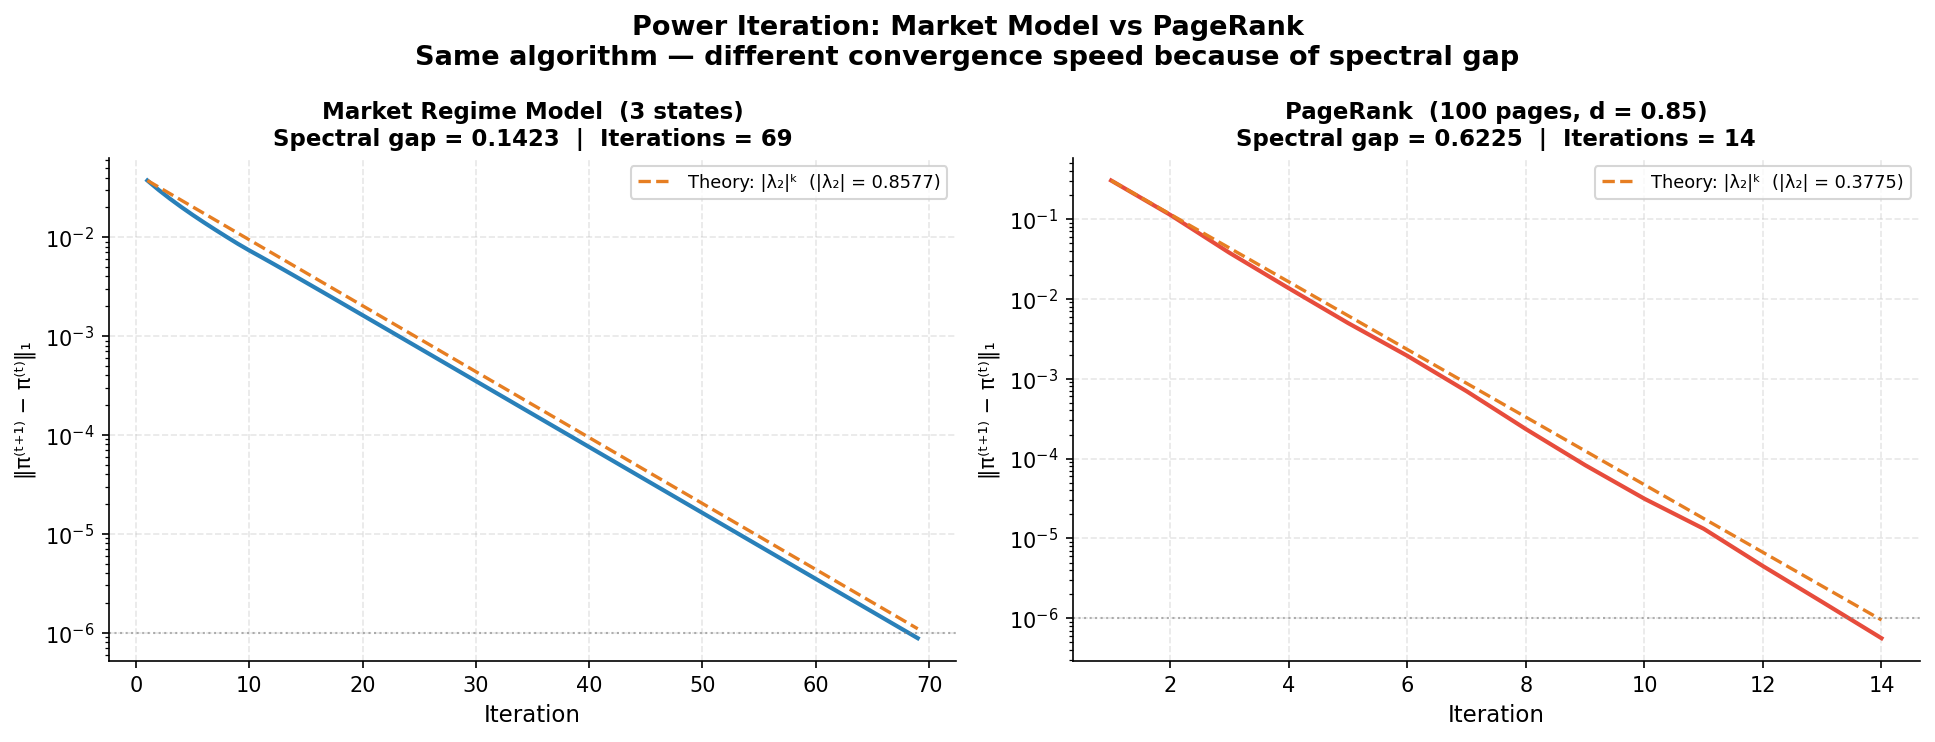

In [35]:
plot_pagerank_comparison(pagerank_cmp, save_path="../visualizations/pagerank_comparison.png", show = False)

In [36]:
print_engine_summary(markov_engine_summary(P, verbose=False))

MARKOV ENGINE & CONVERGENCE ANALYSIS

STATIONARY DISTRIBUTION  π* = π* P
  (Computed via power iteration,  tol = 1e-09)
  Bull      0.419339  ████████████████
  Neutral   0.359183  ██████████████
  Bear      0.221478  ████████
  Sum = 1.0000000000  (should be exactly 1)

METHOD COMPARISON: Power Iteration vs Eigenvector
  Iterations until convergence : 114
  L1  distance  ‖π_pow − π_eig‖₁  : 5.30e-09
  L∞  distance  ‖π_pow − π_eig‖∞  : 2.65e-09
  ✓  Methods agree to within 1e-6

SPECTRAL ANALYSIS
  Perron-Frobenius satisfied : ✓
  λ₁ (dominant eigenvalue)   : 1.00000000  (should be 1.0)
  |λ₂| (second eigenvalue)   : 0.85769491
  Spectral gap 1 − |λ₂|      : 0.14230509
  Predicted convergence rate : |λ₂|ᵏ → 0 at rate 0.857695
  Mixing time estimate       : ~45 iterations

EMPIRICAL CONVERGENCE RATE  (log-linear fit to δᵗ history)
  Empirical |λ₂| from fit     : 0.857695
  Theoretical |λ₂|            : 0.857695
  Fit R²                      : 1.0000

MULTIPLE INITIAL CONDITIONS
  Initia

In [37]:
from src.analysis import *

In [38]:
durations = expected_durations(P)
print(durations)

{'Bull': np.float64(7.595375722543351), 'Neutral': np.float64(4.1685185185185185), 'Bear': np.float64(6.871287128712871)}


Saved → ../visualizations/expected_durations.png


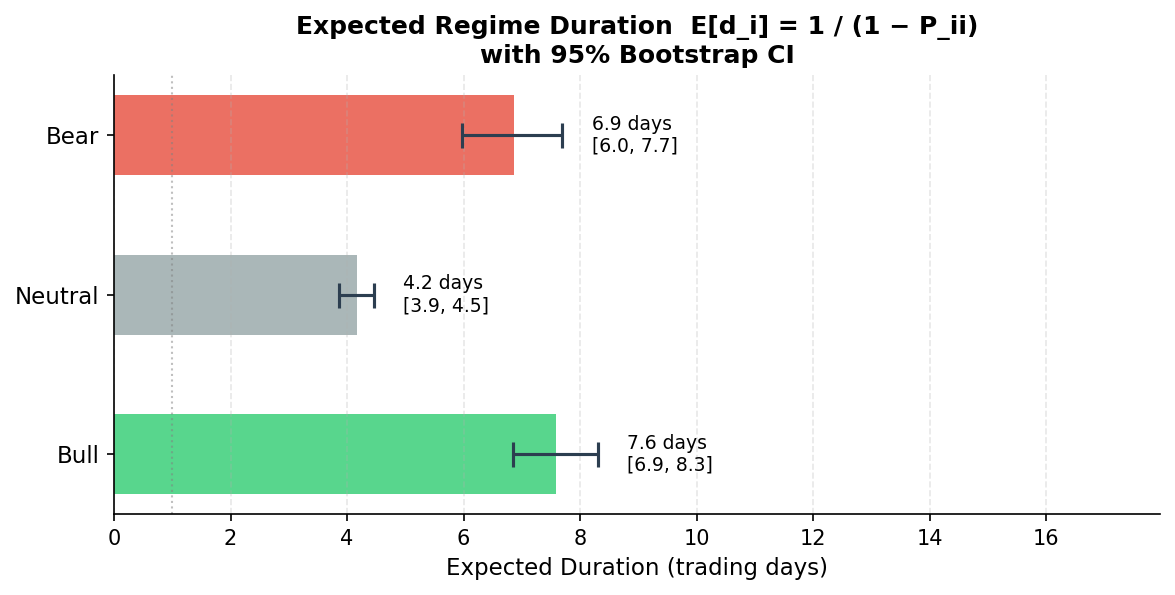

In [39]:
plot_expected_durations(durations, boot, save_path="../visualizations/expected_durations.png", show = False)

In [40]:
sub = sub_period_analysis(regimes)
print(sub)

{'P_pre': array([[0.84820684, 0.14762302, 0.00417014],
       [0.16619718, 0.72488263, 0.10892019],
       [0.00569476, 0.1332574 , 0.86104784]]), 'P_post': array([[8.82926829e-01, 1.16376307e-01, 6.96864111e-04],
       [1.40218304e-01, 7.89252729e-01, 7.05289673e-02],
       [1.93798450e-03, 1.60852713e-01, 8.37209302e-01]]), 'P_full': array([[0.8677309 , 0.13036868, 0.00190042],
       [0.15217391, 0.7595386 , 0.08828749],
       [0.00359454, 0.14306254, 0.85334292]]), 'diff': array([[ 0.03471999, -0.03124671, -0.00347328],
       [-0.02597888,  0.0643701 , -0.03839122],
       [-0.00375678,  0.02759531, -0.02383853]]), 'abs_diff': array([[0.03471999, 0.03124671, 0.00347328],
       [0.02597888, 0.0643701 , 0.03839122],
       [0.00375678, 0.02759531, 0.02383853]]), 'frobenius': 0.09914679180664392, 'max_abs_diff': 0.0643700996913471, 'split_date': '2012-07-17', 'n_pre': 3134, 'n_post': 3134}


Saved → ../visualizations/sub_period_comparison.png


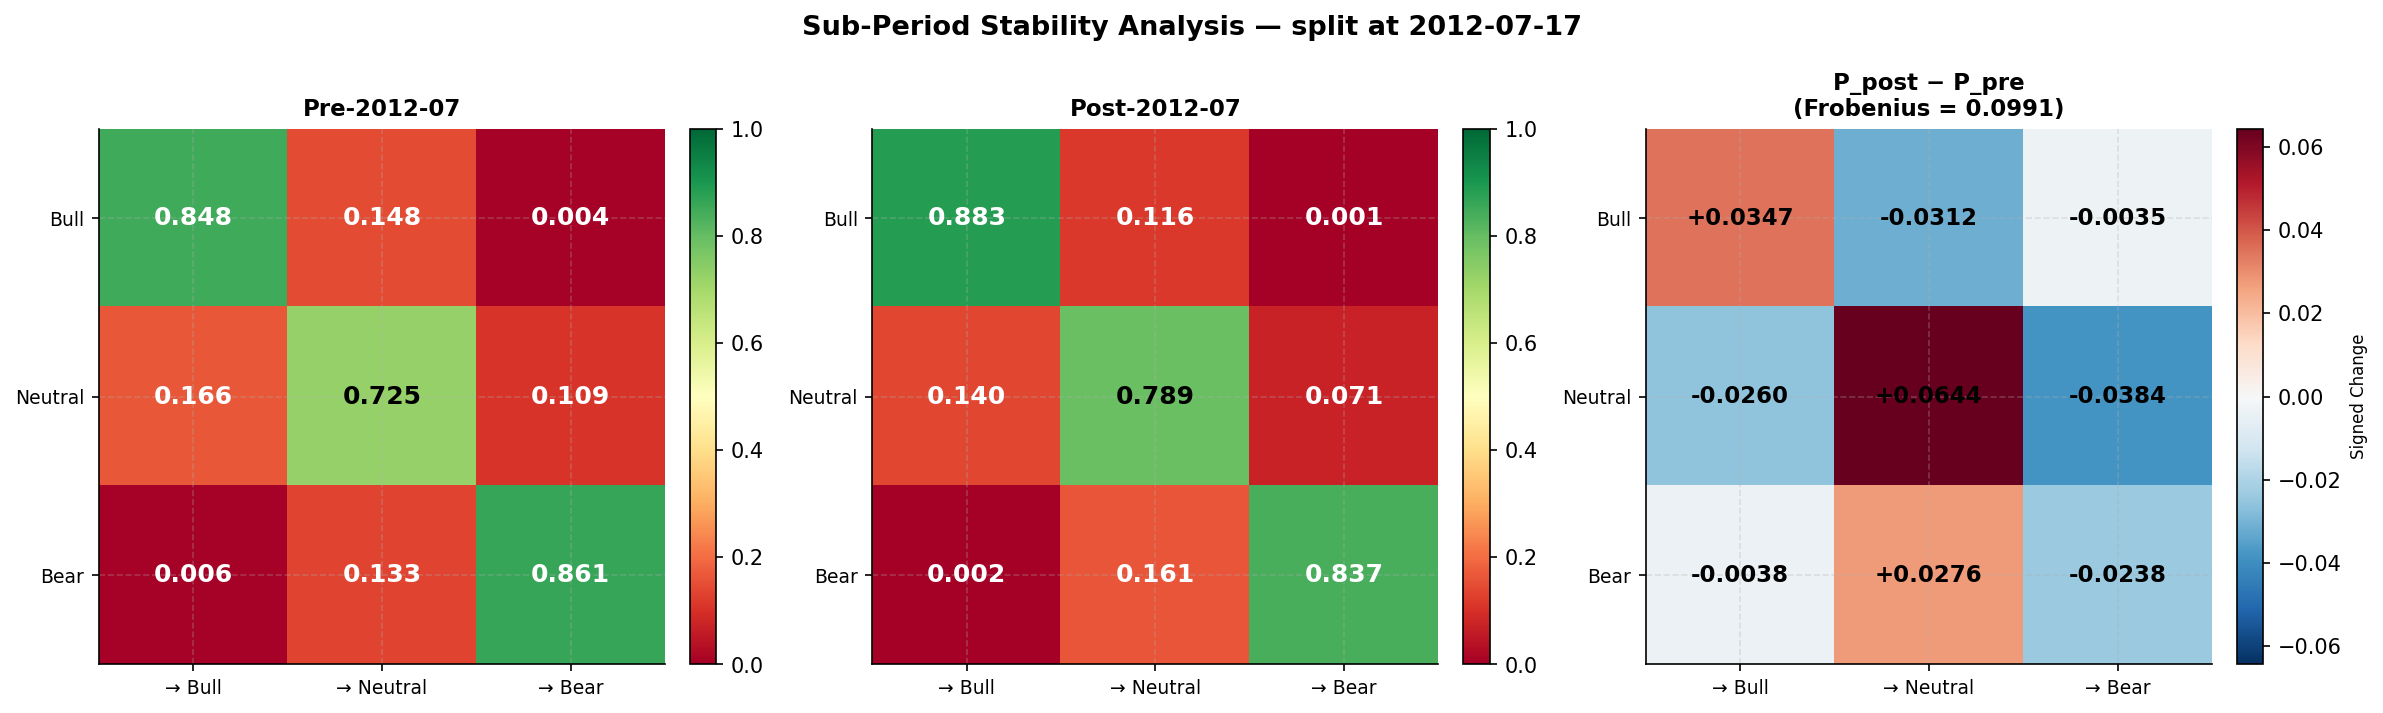

In [41]:
plot_sub_period_comparison(sub, save_path="../visualizations/sub_period_comparison.png", show = False)

In [42]:
M = mean_first_passage_times(P)
print(P)

[[0.86834094 0.13013699 0.00152207]
 [0.15193247 0.76010662 0.08796091]
 [0.00288184 0.1426513  0.85446686]]


Saved → ../visualizations/mfpt_heatmap.png


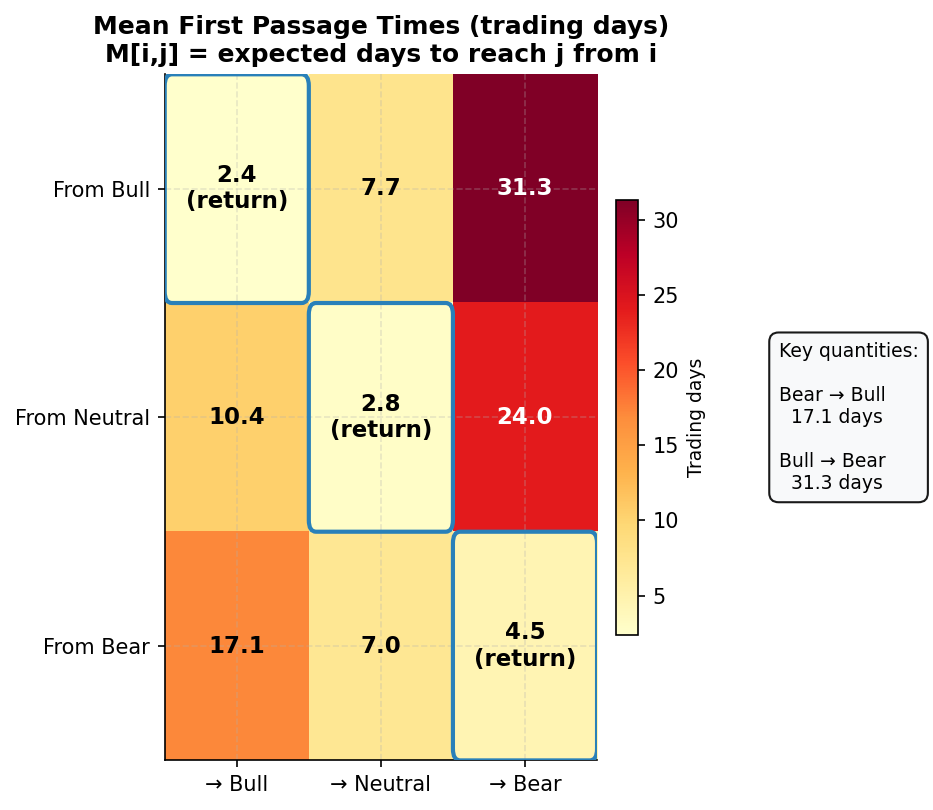

In [43]:
plot_mfpt_heatmap(mfpt_summary(M), save_path="../visualizations/mfpt_heatmap.png", show = False)

Saved → ../visualizations/mfpt_financial.png


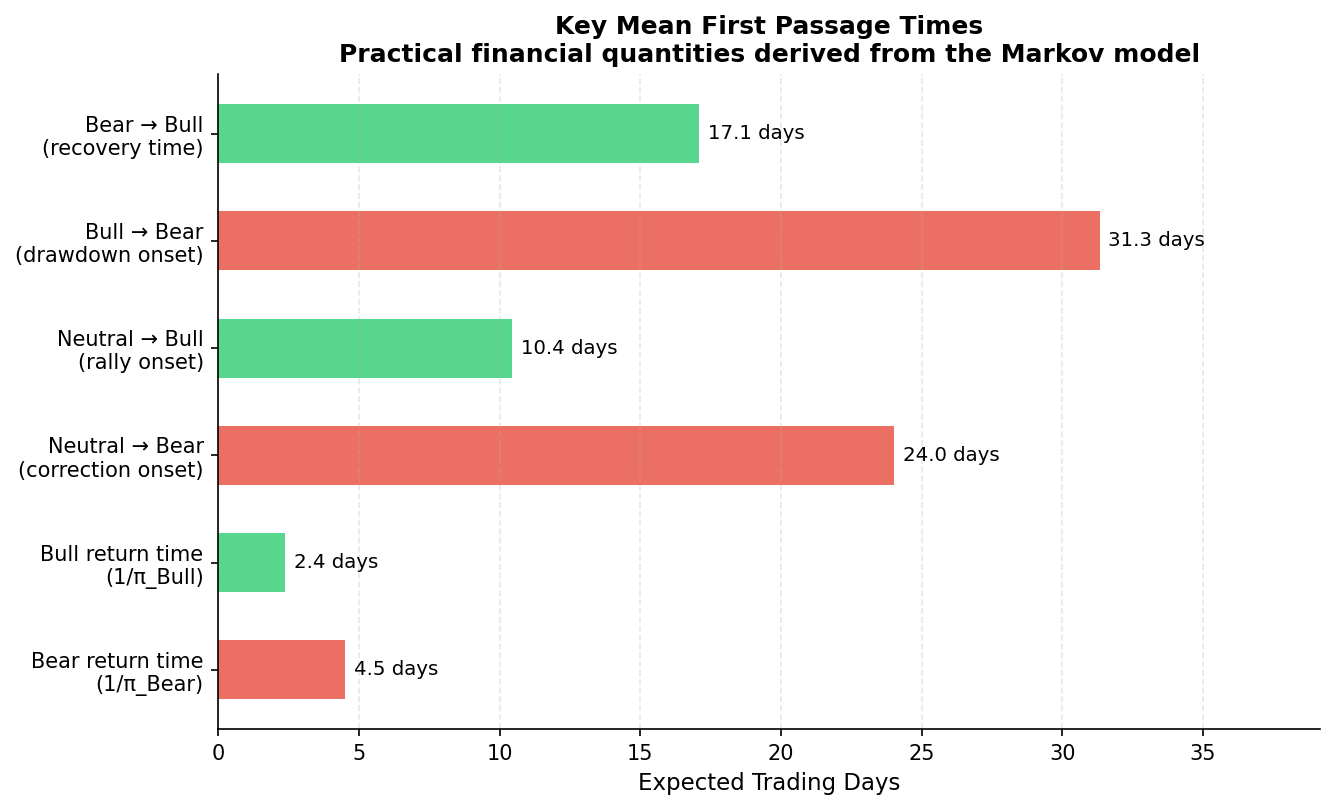

In [44]:
plot_mfpt_financial(mfpt_summary(M), save_path="../visualizations/mfpt_financial.png", show = False)

In [45]:
markov_order_test(regimes)

{'ll_first_order': -3236.07154867944,
 'll_second_order': -3086.133771768503,
 'test_statistic': 299.87555382187475,
 'df': 12,
 'p_value': 0.0,
 'reject_h0': True,
 'conclusion': 'REJECT H0 (p = 0.0000 < 0.05): The data provide significant evidence that the second-order Markov model fits better. Markets carry memory beyond a single lag — the first-order Markov assumption is a simplification.',
 'n_transitions': 6266,
 'second_order_counts': array([[2053,  228,    1],
        [  99,  233,   10],
        [   0,    2,    2],
        [ 226,  113,    3],
        [ 225, 1356,  130],
        [   1,   58,  138],
        [   3,    1,    0],
        [  18,  122,   58],
        [   3,  137, 1046]]),
 'second_order_P': array([[8.99649430e-01, 9.99123576e-02, 4.38212095e-04],
        [2.89473684e-01, 6.81286550e-01, 2.92397661e-02],
        [0.00000000e+00, 5.00000000e-01, 5.00000000e-01],
        [6.60818713e-01, 3.30409357e-01, 8.77192982e-03],
        [1.31502046e-01, 7.92518995e-01, 7.59789597

Saved → ../visualizations/order_tes.png


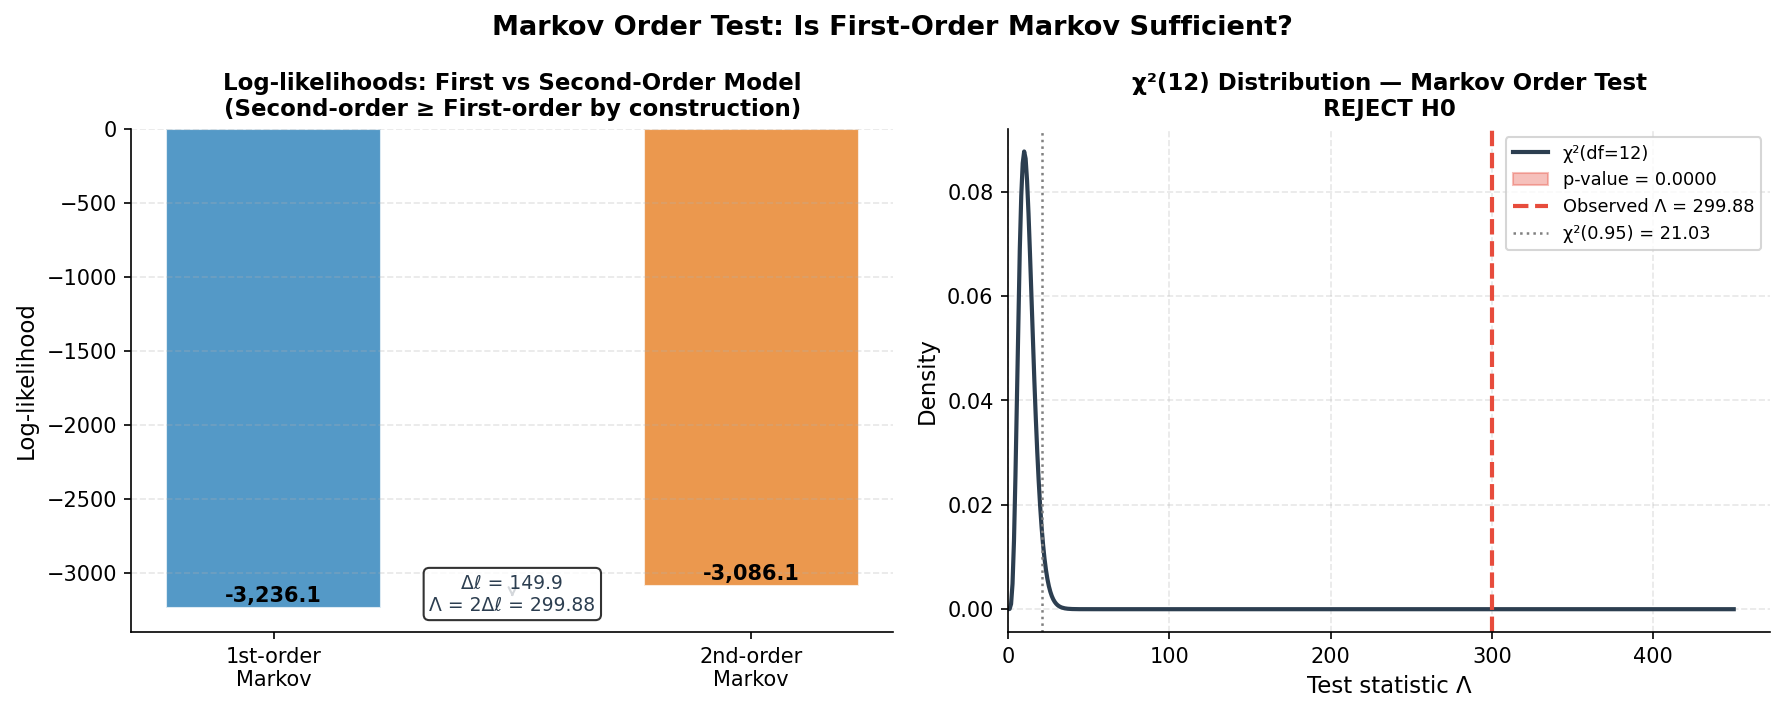

In [46]:
plot_order_test(markov_order_test(regimes), save_path="../visualizations/order_tes.png", show = False)

In [47]:
sensitivity_analysis(prices)

{'results':     window  threshold   pi_Bull  pi_Neutral   pi_Bear  n_obs  \
 0        5       0.01  0.350024    0.403910  0.246066   6283   
 1        5       0.02  0.167859    0.689080  0.143062   6283   
 2        5       0.03  0.081386    0.837387  0.081227   6283   
 3       10       0.01  0.443585    0.284956  0.271460   6278   
 4       10       0.02  0.278075    0.537819  0.184106   6278   
 5       10       0.03  0.160356    0.717945  0.121699   6278   
 6       20       0.01  0.538719    0.177502  0.283779   6268   
 7       20       0.02  0.419216    0.359146  0.221638   6268   
 8       20       0.03  0.295213    0.533975  0.170812   6268   
 9       60       0.01  0.640635    0.088679  0.270686   6228   
 10      60       0.02  0.584830    0.177678  0.237492   6228   
 11      60       0.03  0.521328    0.273894  0.204779   6228   
 
     frobenius_from_baseline  is_baseline  
 0                  0.331790        False  
 1                  0.471799        False  
 2        

Saved → ../visualizations/sensitivity_grid.png


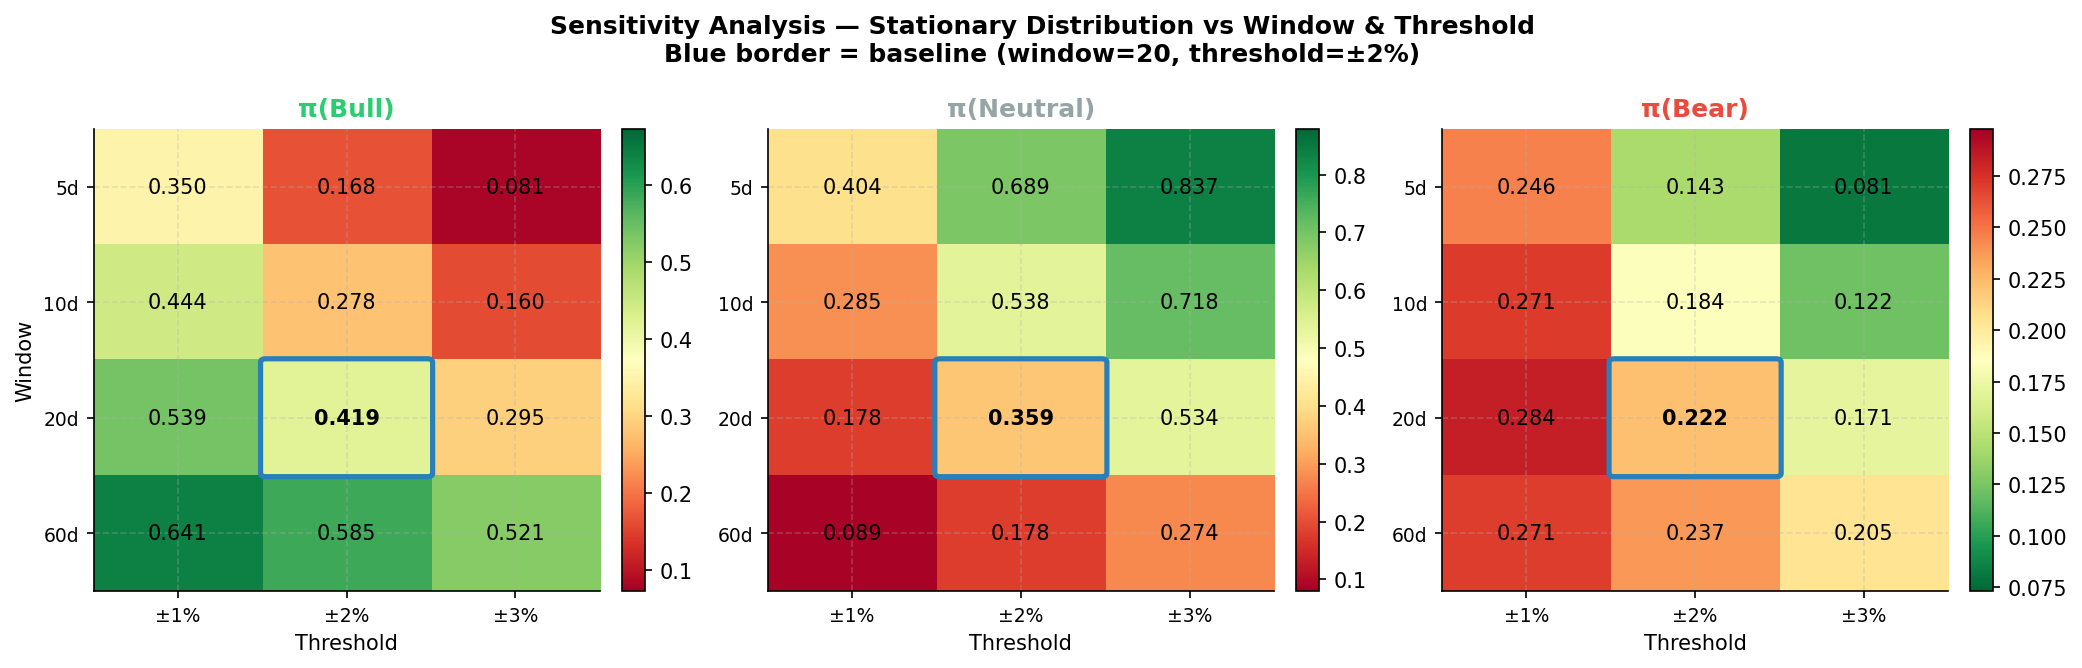

In [48]:
plot_sensitivity_grid(sensitivity_analysis(prices), save_path="../visualizations/sensitivity_grid.png", show = False)

In [49]:
conditional_exit_analysis(P, M)

{'exit_destinations': {'Bull': {'Neutral': np.float64(0.9884393063583813),
   'Bear': np.float64(0.011560693641618495)},
  'Neutral': {'Bull': np.float64(0.6333333333333333),
   'Bear': np.float64(0.36666666666666664)},
  'Bear': {'Bull': np.float64(0.019801980198019802),
   'Neutral': np.float64(0.9801980198019802)}},
 'most_likely_after_bear': 'Neutral',
 'bear_exit_probs': {'Bull': np.float64(0.019801980198019802),
  'Neutral': np.float64(0.9801980198019802)},
 'duration_in_bear': np.float64(6.871287128712871),
 'expected_bear_to_bull': np.float64(17.10484286450283),
 'expected_bull_to_bear': np.float64(31.326378155589886),
 'expected_neutral_to_bear': np.float64(24.00855801705878),
 'expected_neutral_to_bull': np.float64(10.44029423550289)}

In [50]:
print_findings(compile_findings(prices, regimes, P, verbose = False))

ANALYSIS AND INTERPRETATION

EXPECTED REGIME DURATIONS  E[d_i] = 1 / (1 - P[i,i])

SUB-PERIOD STABILITY  (split: 2012-07-17)
  Pre-split  : 3,134 observations
  Post-split : 3,134 observations
  Frobenius norm of (P_post - P_pre) : 0.0991
  Max absolute element change        : 0.0644

  Signed difference matrix  (P_post - P_pre)
                    Bull     Neutral        Bear
  Bull         +0.0347   -0.0312   -0.0035
  Neutral      -0.0260   +0.0644   -0.0384
  Bear         -0.0038   +0.0276   -0.0238

  Interpretation: values near 0 → stationarity; large values →
  transition dynamics shifted between sub-periods (non-stationarity).

MEAN FIRST PASSAGE TIMES (trading days)
  M[i,j] = expected days to reach state j from state i

                    → Bull     → Neutral        → Bear
  Bull               2.4 *         7.7          31.3  
  Neutral           10.4           2.8 *        24.0  
  Bear              17.1           7.0           4.5 *
  (* diagonal = mean return time = 1/π_i

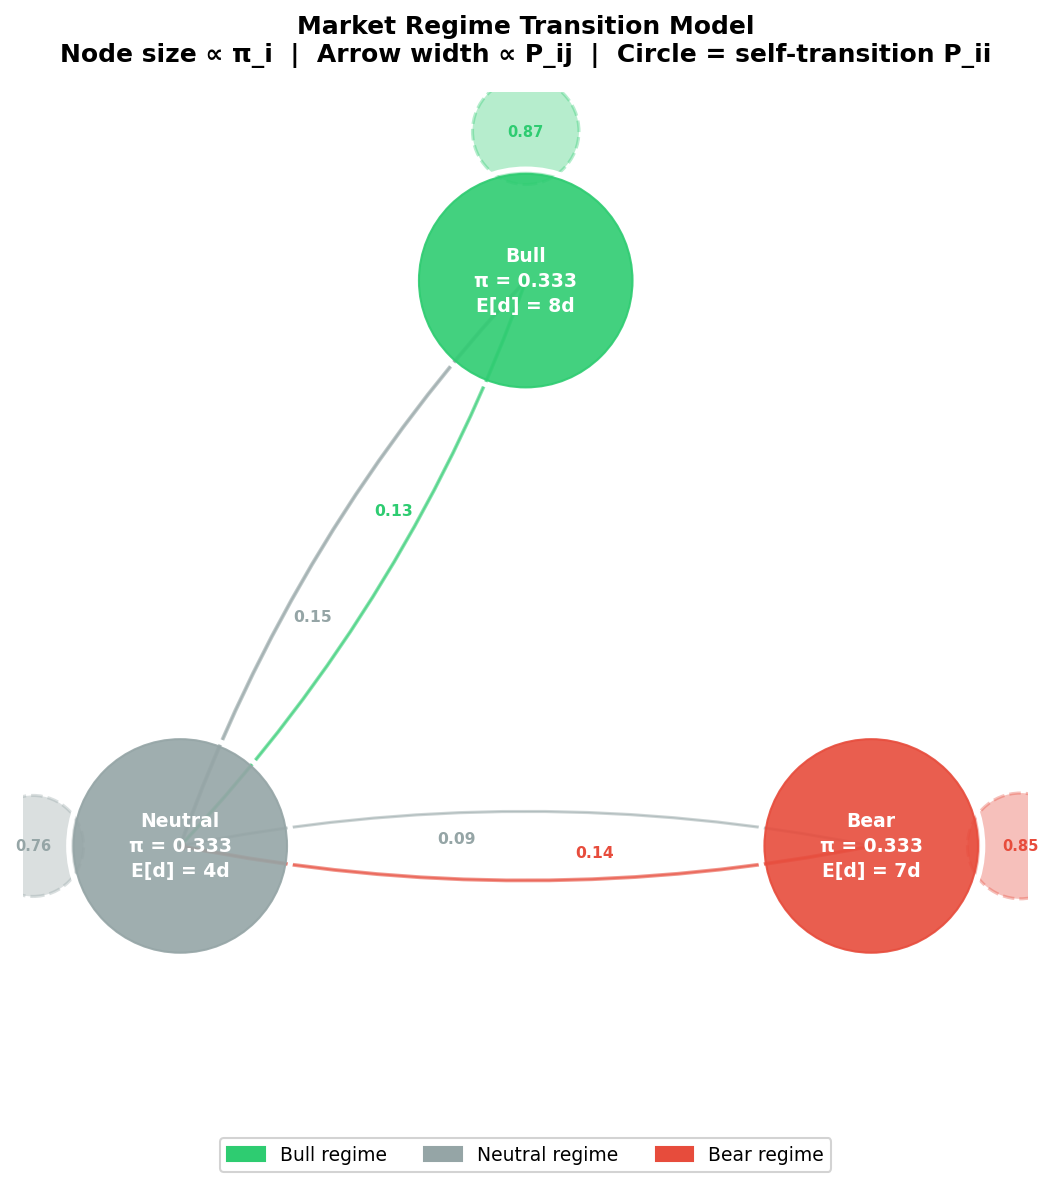

In [53]:
plot_regime_cycle(P, power_iteration(P)["pi0"], durations, show = False)